<a href="https://colab.research.google.com/github/kl2400032181/Reinforcement-Learning-Experiments/blob/main/Experiment_8_Rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

State-value estimates:
 State  Visits  Estimated Value
     0    5391           -8.045
     1    3537           -7.613
     2    2605           -6.969
     3    2156           -6.233
     4    3584           -7.505
     5    2834           -6.767
     6    2172           -5.640
     7    1894           -4.517
     8    2563           -6.799
     9    2183           -5.686
    10    1614           -3.538
    11    1192            0.102
    12    1983           -6.357
    13    1687           -4.586
    14    1046            0.171
    15       0              NaN

4 x 4 State-Value Matrix:
[[-8.04 -7.61 -6.97 -6.23]
 [-7.51 -6.77 -5.64 -4.52]
 [-6.8  -5.69 -3.54  0.1 ]
 [-6.36 -4.59  0.17   nan]]


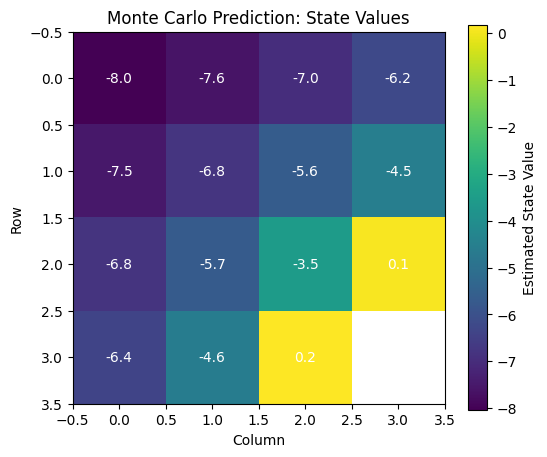


Number of episodes: 1000
Average episode return: -30.083


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("gridworld_monte_carlo.csv")

# 1. Calculate state values using average returns
state_values = df.groupby("state")["return"].mean()

# 2. Count recorded visits to each state
state_visits = df.groupby("state")["return"].count()

# 3. Display the results
results = pd.DataFrame({
    "State": range(16)
})
results["Visits"] = results["State"].map(state_visits).fillna(0).astype(int)
results["Estimated Value"] = results["State"].map(state_values)

print("State-value estimates:")
print(results.round(3).to_string(index=False))

# 4. Display the 4 x 4 state-value matrix
value_grid = (
    results.set_index("State")["Estimated Value"]
    .reindex(range(16))
    .to_numpy()
    .reshape(4, 4)
)

print("\n4 x 4 State-Value Matrix:")
print(np.round(value_grid, 2))

# 5. Plot the state values
plt.figure(figsize=(6, 5))
plt.imshow(value_grid, cmap="viridis")
plt.colorbar(label="Estimated State Value")

for s in range(16):
    r, c = divmod(s, 4)
    value = value_grid[r, c]
    label = "G" if s == 15 else (
        "N/A" if np.isnan(value) else f"{value:.1f}"
    )
    plt.text(c, r, label, ha="center",
             va="center", color="white")

plt.title("Monte Carlo Prediction: State Values")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

# 6. Calculate average total episode reward
episode_returns = df.groupby("episode")["reward"].sum()

print("\nNumber of episodes:", len(episode_returns))
print("Average episode return:",
      round(episode_returns.mean(), 3))

In [2]:

import pandas as pd

# Load the dataset
df = pd.read_csv("gridworld_monte_carlo.csv")

print("Dataset loaded successfully")
print("Total records:", len(df))
print("Total episodes:", df["episode"].nunique())

# Display the first 10 records
print("\nSample records:")
print(df.head(10))

# Display one complete episode
episode_number = 1
episode = df[df["episode"] == episode_number]

print("\nEpisode", episode_number)
print(episode[[
    "step", "state", "action", "reward", "next_state"
]].to_string(index=False))

print("\nTotal steps:", len(episode))
print("Total reward:", episode["reward"].sum())

Dataset loaded successfully
Total records: 36441
Total episodes: 1000

Sample records:
   episode  step  state action  reward  next_state    return
0        1     1      0      U      -1           0 -6.998107
1        1     2      0      U      -1           0 -6.664564
2        1     3      0      L      -1           0 -6.293960
3        1     4      0      D      -1           4 -5.882177
4        1     5      4      D      -1           8 -5.424642
5        1     6      8      D      -1          12 -4.916268
6        1     7     12      U      -1           8 -4.351409
7        1     8      8      U      -1           4 -3.723788
8        1     9      4      R      -1           5 -3.026431
9        1    10      5      U      -1           1 -2.251590

Episode 1
 step  state action  reward  next_state
    1      0      U      -1           0
    2      0      U      -1           0
    3      0      L      -1           0
    4      0      D      -1           4
    5      4      D      -1    

State-Value Estimates
State 0: V = -8.496, Visits = 1000
State 1: V = -8.138, Visits = 850
State 2: V = -7.633, Visits = 664
State 3: V = -7.024, Visits = 472
State 4: V = -8.020, Visits = 853
State 5: V = -7.348, Visits = 873
State 6: V = -6.177, Visits = 763
State 7: V = -4.882, Visits = 583
State 8: V = -7.150, Visits = 686
State 9: V = -6.004, Visits = 774
State 10: V = -3.749, Visits = 723
State 11: V = -0.396, Visits = 555
State 12: V = -6.535, Visits = 466
State 13: V = -4.510, Visits = 554
State 14: V = 0.103, Visits = 513
State 15: Terminal state, V = 0

State-Value Matrix:
[[-8.5  -8.14 -7.63 -7.02]
 [-8.02 -7.35 -6.18 -4.88]
 [-7.15 -6.   -3.75 -0.4 ]
 [-6.53 -4.51  0.1   0.  ]]


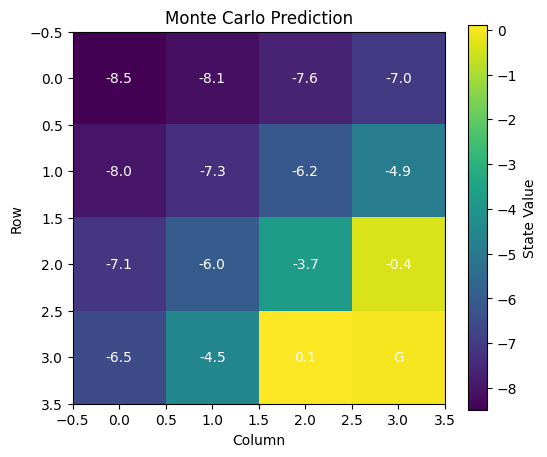

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("gridworld_monte_carlo.csv")

# Keep only the first visit to each state in each episode
first_visit = df.drop_duplicates(
    subset=["episode", "state"],
    keep="first"
)

# Calculate state-value estimates
V = first_visit.groupby("state")["return"].mean()

# Count first visits used in each estimate
counts = first_visit.groupby("state").size()

print("State-Value Estimates")
for state in range(16):
    if state == 15:
        print(f"State {state}: Terminal state, V = 0")
    elif state in V.index:
        print(
            f"State {state}: V = {V[state]:.3f}, "
            f"Visits = {counts[state]}"
        )
    else:
        print(f"State {state}: Not visited")

# Create 4 x 4 value matrix
grid = np.full(16, np.nan)
for state, value in V.items():
    grid[int(state)] = value

grid[15] = 0
grid = grid.reshape(4, 4)

print("\nState-Value Matrix:")
print(np.round(grid, 2))

# Plot the state values
plt.figure(figsize=(6, 5))
plt.imshow(grid, cmap="viridis")
plt.colorbar(label="State Value")

for state in range(16):
    row, col = divmod(state, 4)
    value = grid[row, col]
    label = "G" if state == 15 else (
        "N/A" if np.isnan(value) else f"{value:.1f}"
    )
    plt.text(col, row, label, ha="center",
             va="center", color="white")

plt.title("Monte Carlo Prediction")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

In [4]:

import pandas as pd
import numpy as np
import random
from collections import defaultdict

# Load and inspect the dataset
df = pd.read_csv("gridworld_monte_carlo.csv")
print("Dataset episodes:", df["episode"].nunique())
print("Dataset records:", len(df))

# Grid World settings
SIZE = 4
START = 0
GOAL = 15
GAMMA = 0.9
EPSILON = 0.1
EPISODES = 5000
MAX_STEPS = 50

ACTIONS = ["U", "D", "L", "R"]
ARROWS = ["^", "v", "<", ">"]

# Environment
def step(state, action):
    row, col = divmod(state, SIZE)

    if action == "U":
        row = max(0, row - 1)
    elif action == "D":
        row = min(SIZE - 1, row + 1)
    elif action == "L":
        col = max(0, col - 1)
    else:
        col = min(SIZE - 1, col + 1)

    next_state = row * SIZE + col
    reward = 10 if next_state == GOAL else -1

    return next_state, reward, next_state == GOAL

# Action-value estimates
Q = np.zeros((SIZE * SIZE, len(ACTIONS)))
returns_sum = defaultdict(float)
returns_count = defaultdict(int)

def generate_episode():
    state = START
    episode = []

    for _ in range(MAX_STEPS):
        # Epsilon-soft action selection
        if random.random() < EPSILON:
            action = random.randrange(len(ACTIONS))
        else:
            best_actions = np.flatnonzero(
                Q[state] == Q[state].max()
            )
            action = random.choice(best_actions)

        next_state, reward, done = step(
            state, ACTIONS[action]
        )

        episode.append((state, action, reward))
        state = next_state

        if done:
            break

    return episode

# Monte Carlo control
for ep in range(EPISODES):
    episode = generate_episode()
    G = 0
    visited = set()

    for state, action, reward in reversed(episode):
        G = reward + GAMMA * G
        pair = (state, action)

        # First-visit state-action update
        if pair not in visited:
            visited.add(pair)
            returns_sum[pair] += G
            returns_count[pair] += 1

            Q[state, action] = (
                returns_sum[pair] / returns_count[pair]
            )

# Display learned policy
print("\nLearned Policy:")

for state in range(SIZE * SIZE):
    if state == GOAL:
        print("G", end=" ")
    else:
        print(ARROWS[np.argmax(Q[state])], end=" ")

    if state % SIZE == SIZE - 1:
        print()

print("\nAction-Value Function Q(s,a):")
print(np.round(Q, 2))

# Save action-value estimates
q_data = []

for state in range(SIZE * SIZE):
    for i, action in enumerate(ACTIONS):
        q_data.append({
            "state": state,
            "action": action,
            "Q_value": Q[state, i],
            "visits": returns_count[(state, i)]
        })

pd.DataFrame(q_data).to_csv(
    "monte_carlo_control_results.csv", index=False
)

print("\nSaved: monte_carlo_control_results.csv")

Dataset episodes: 1000
Dataset records: 36441

Learned Policy:
v v v > 
> > v < 
v > v v 
> > > G 

Action-Value Function Q(s,a):
[[-0.09  1.11 -0.32  1.01]
 [ 0.17  2.53 -1.23  0.93]
 [-1.17  4.06 -0.6  -5.25]
 [-4.63 -2.48 -0.35 -0.02]
 [-0.28  1.69  1.09  2.47]
 [ 1.11  3.54  1.08  4.04]
 [ 2.3   5.87  2.34  2.53]
 [-9.32  3.49  4.07  3.12]
 [ 0.58  3.86  1.82  2.04]
 [ 2.58  5.57  1.2   5.8 ]
 [ 4.04  7.87  3.61  5.16]
 [ 2.28 10.    5.67  3.71]
 [ 0.49  2.07  3.22  5.76]
 [ 4.18  5.28  3.02  7.85]
 [ 5.8   7.8   5.8  10.  ]
 [ 0.    0.    0.    0.  ]]

Saved: monte_carlo_control_results.csv


# New Section